# Homework 5 - Exercise 5

Extracted from `HW5_completed.ipynb`. This notebook contains only Exercise 5 plus the shared helper cell needed to run it independently.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor


def assign_leaf(predictions, y, left, right):
    predictions[left:right + 1] = np.mean(y[left:right + 1])


def best_split_index(y, left, right):
    if left >= right:
        return None

    segment = y[left:right + 1]
    prefix_sum = np.cumsum(segment)
    prefix_sq_sum = np.cumsum(segment ** 2)
    total_sum = prefix_sum[-1]
    total_sq_sum = prefix_sq_sum[-1]

    best_index = None
    best_score = float("inf")
    for offset in range(len(segment) - 1):
        left_count = offset + 1
        right_count = len(segment) - left_count
        left_sum = prefix_sum[offset]
        left_sq_sum = prefix_sq_sum[offset]
        right_sum = total_sum - left_sum
        right_sq_sum = total_sq_sum - left_sq_sum
        left_sse = left_sq_sum - (left_sum ** 2) / left_count
        right_sse = right_sq_sum - (right_sum ** 2) / right_count
        score = float(left_sse + right_sse)
        if score < best_score - 1e-12:
            best_score = score
            best_index = left + offset
    return best_index


def my_tree_regressor(y, left, right, max_depth, predictions, level=0):
    if left > right:
        return
    if left == right or level == max_depth:
        assign_leaf(predictions, y, left, right)
        return

    split = best_split_index(y, left, right)
    if split is None:
        assign_leaf(predictions, y, left, right)
        return

    my_tree_regressor(y, left, split, max_depth, predictions, level=level + 1)
    my_tree_regressor(y, split + 1, right, max_depth, predictions, level=level + 1)


def run_custom_tree(y, max_depth):
    predictions = np.zeros_like(y)
    my_tree_regressor(y, 0, len(y) - 1, max_depth, predictions)
    return predictions


## Exercise 5


In [2]:
# Reproduce the noisy sin(x) regression dataset from the assignment prompt.
rng = np.random.RandomState(1)
X = np.sort(6.3 * rng.rand(100, 1), axis=0)
y = np.sin(X).ravel()
y += 0.3 * (0.5 - rng.rand(len(X)))

# Fit scikit-learn's tree regressor at the two requested maximum depths.
regr_1 = DecisionTreeRegressor(max_depth=2, random_state=1)
regr_2 = DecisionTreeRegressor(max_depth=5, random_state=1)
regr_1.fit(X, y)
regr_2.fit(X, y)

sklearn_depth_2 = regr_1.predict(X)
sklearn_depth_5 = regr_2.predict(X)

# Run the custom recursive implementation on the same y-values. Since the custom
# code is designed only to predict at the sampled x-points, it returns one value
# per training input, matching the arrays above.
custom_depth_2 = run_custom_tree(y, max_depth=2)
custom_depth_5 = run_custom_tree(y, max_depth=5)

# The maximum absolute difference is a direct numerical check that the custom
# implementation agrees with scikit-learn on the sampled points.
print("max |sklearn - custom| at depth 2:", np.max(np.abs(sklearn_depth_2 - custom_depth_2)))
print("max |sklearn - custom| at depth 5:", np.max(np.abs(sklearn_depth_5 - custom_depth_5)))


max |sklearn - custom| at depth 2: 2.220446049250313e-16
max |sklearn - custom| at depth 5: 0.0


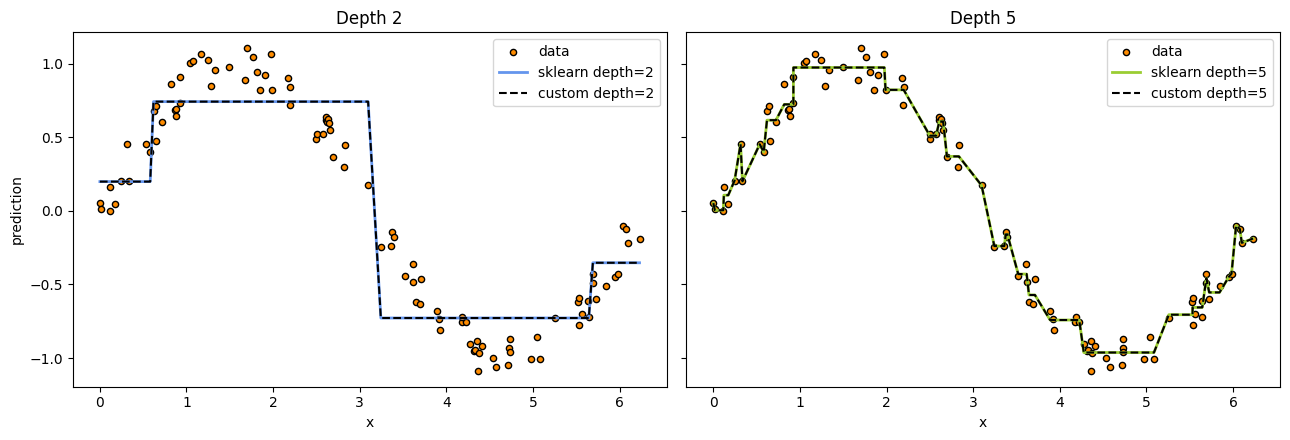

In [3]:
# Plot scikit-learn and custom predictions on top of the same noisy dataset so the
# agreement can be checked visually in addition to numerically.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

axes[0].scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
axes[0].plot(X, sklearn_depth_2, color="cornflowerblue", linewidth=2, label="sklearn depth=2")
axes[0].plot(X, custom_depth_2, color="black", linestyle="--", linewidth=1.5, label="custom depth=2")
axes[0].set_title("Depth 2")
axes[0].set_xlabel("x")
axes[0].set_ylabel("prediction")
axes[0].legend()

axes[1].scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
axes[1].plot(X, sklearn_depth_5, color="yellowgreen", linewidth=2, label="sklearn depth=5")
axes[1].plot(X, custom_depth_5, color="black", linestyle="--", linewidth=1.5, label="custom depth=5")
axes[1].set_title("Depth 5")
axes[1].set_xlabel("x")
axes[1].legend()

plt.tight_layout()
# plt.savefig("ex5_tree_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


**Exercise 5 answer.** The custom tree regressor matches scikit-learn on the sampled points to machine precision:

- depth 2: `2.22e-16`
- depth 5: `0.0`

So the implementation is correctly reproducing the same piecewise-constant regression values at the training inputs. The stopping rule for single-point intervals is handled by assigning the mean of that interval, which in the one-point case is just that point itself.
